In [1]:
# # install progress bar
# !pip install tqdm
# !pip install scqubits

In [3]:
import numpy as np
import scqubits
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
from typing import List
def dressed_transition_frequency_over_2pi(hilbertspace,s0: List[int], s1: List[int]) -> float:
    s0 = hilbertspace.dressed_index(s0)
    s1 = hilbertspace.dressed_index(s1)
    return abs(hilbertspace.energy_by_dressed_index(s1) - hilbertspace.energy_by_dressed_index(s0))

def replace_non_float64_with_none(lst):
    for i in range(len(lst)):
        if type(lst[i]) is not np.float64:
            lst[i] = None
    return lst
    
def sweep_resonator_frequency_for_detunning(
                                            Er_vals = np.linspace(2,4, 100),
                                            EJ = 3,
                                            EC =0.6,
                                            EL = 0.13,
                                            flux = 1):
    
    chi0_list = []
    chi1_list = []
    chi2_list = []
    
    qbt = scqubits.Fluxonium(
            EJ=EJ,
            EC=EC,
            EL=EL,
            flux=flux,
            cutoff=80,
            truncated_dim=9
        )

    for Er in tqdm(Er_vals,desc='iterating over Er'):
        osc = scqubits.Oscillator(
            E_osc=Er,
            truncated_dim=5
        )
        hilbertspace = scqubits.HilbertSpace([qbt, osc])
        g_strength = 0.1
        hilbertspace.add_interaction(
            g_strength=g_strength,
            op1=qbt.n_operator,
            op2=osc.creation_operator,
            add_hc=True
        )
        hilbertspace.generate_lookup()
        chi0 = dressed_transition_frequency_over_2pi(hilbertspace,(0,0),(0,1)) - Er
        chi1 = dressed_transition_frequency_over_2pi(hilbertspace,(1,0),(1,1)) - Er
        chi2 = dressed_transition_frequency_over_2pi(hilbertspace,(2,0),(2,1)) - Er

        chi0_list.append(chi0)
        chi1_list.append(chi1)
        chi2_list.append(chi2)

    chi0_list = replace_non_float64_with_none(chi0_list)
    chi1_list = replace_non_float64_with_none(chi1_list)
    chi2_list = replace_non_float64_with_none(chi2_list)
    plt.figure(figsize=(6,4))
    plt.plot(Er_vals, chi0_list, label=r'$\chi_{0}$')
    plt.plot(Er_vals, chi1_list, label=r'$\chi_{1}$')
    plt.plot(Er_vals, chi2_list, label=r'$\chi_{2}$')

    plt.legend()
    # plt.ylim([-100,100])
    plt.gca().yaxis.grid(True)
    plt.gca().xaxis.grid(True)
    plt.xlabel("resonator frequency (GHz)")
    plt.ylabel(r"\chi_{j}")
    plt.show()



03 transition: 7.294189741417998
12 transition: 0.010937893779849883


iterating over Er: 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]


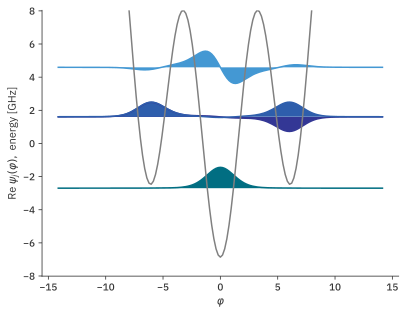

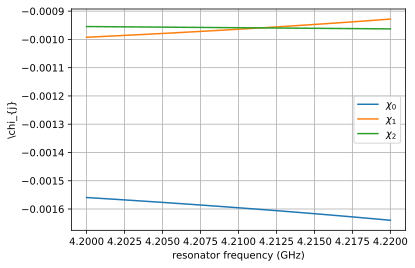

In [6]:
EJ = 6.86
EC = 1.46
EL = 0.23


qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")
fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(4.2,4.22, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 0)

03 transition: 6.113277082682078
12 transition: 0.014436392135007026


iterating over Er: 100%|██████████| 100/100 [00:52<00:00,  1.92it/s]


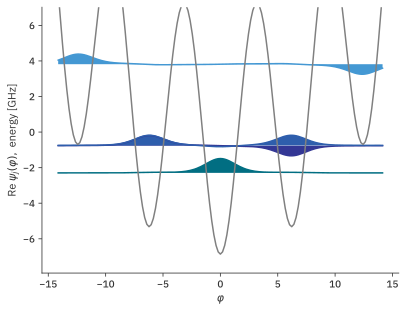

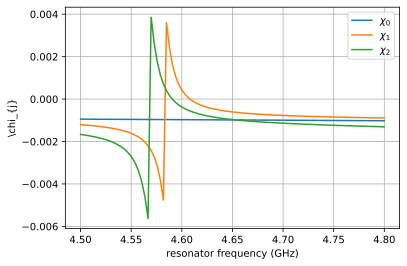

In [31]:
EJ = 6.86
EC = 1.87
EL = 0.079


qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")
fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(4.5,4.8, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 0)

2.823824155909258


iterating over Er: 100%|██████████| 100/100 [00:43<00:00,  2.32it/s]


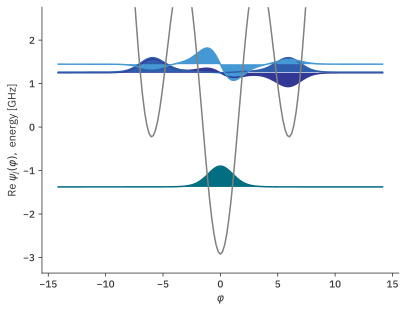

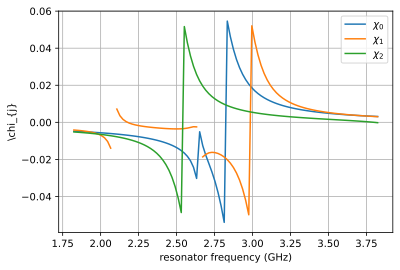

In [14]:
EJ = 2.923
EC = 0.45
EL = 0.14335

qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")

fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(transition03-1,transition03+1, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 1)


3.1685312254319506


iterating over Er: 100%|██████████| 100/100 [00:42<00:00,  2.34it/s]


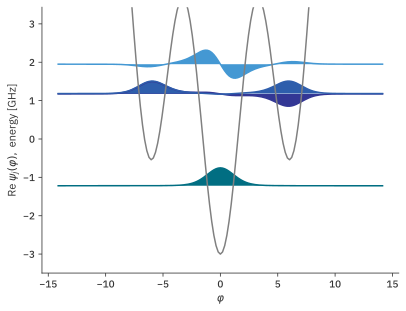

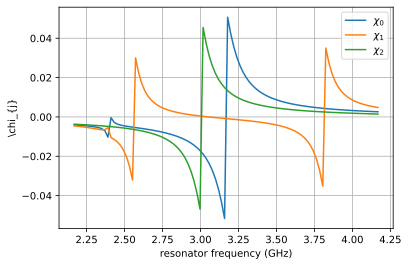

In [12]:
EJ = 3
EC =0.6
EL = 0.13

qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")
fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(transition03-1,transition03+1, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 1)


03 transition: 3.3288749661799137
12 transition: 0.011447983200501888


iterating over Er: 100%|██████████| 100/100 [00:46<00:00,  2.15it/s]


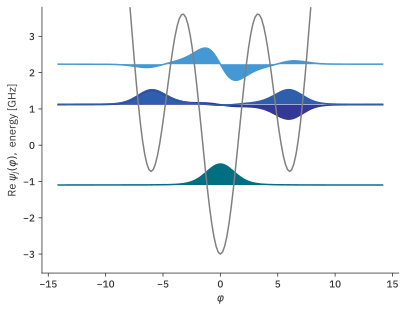

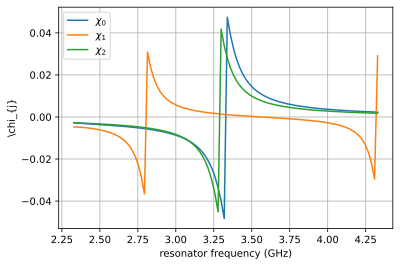

In [26]:
EJ = 3
EC = 0.7
EL = 0.12


qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")
fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(transition03-1,transition03+1, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 1)


03 transition: 3.3870394018930847
12 transition: 0.011525677262492096


iterating over Er: 100%|██████████| 100/100 [00:54<00:00,  1.83it/s]


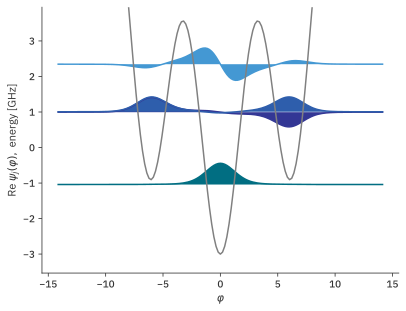

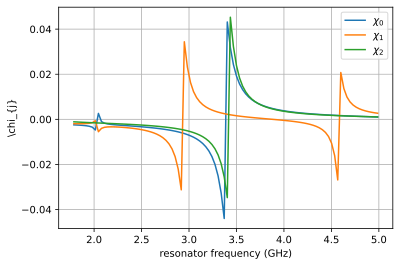

In [22]:
EJ = 3
EC = 0.75
EL = 0.11


qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")
fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(transition03-1.6,transition03+1.6, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 1)


03 transition: 3.385013114365086
12 transition: 0.008437678785270908


iterating over Er: 100%|██████████| 100/100 [00:35<00:00,  2.79it/s]


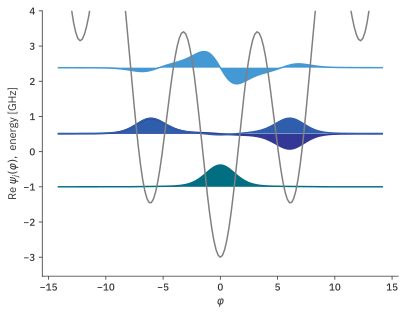

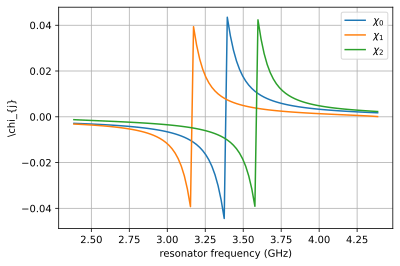

In [28]:
EJ = 3
EC = 0.8
EL = 0.08


qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")
fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(transition03-1,transition03+1, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 1)


03 transition: 2.3296401581160326
12 transition: 0.010000712236649445


iterating over Er: 100%|██████████| 100/100 [00:33<00:00,  2.98it/s]


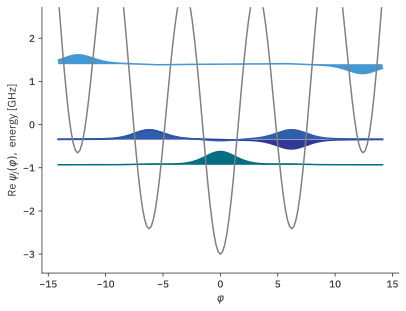

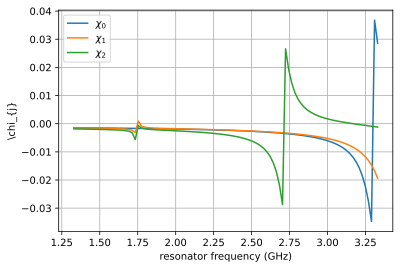

In [25]:
EJ = 3
EC = 0.8923
EL = 0.03


qbt = scqubits.Fluxonium(EJ = EJ,
                    EC =EC,
                    EL = EL,
                    flux = 1,cutoff = 110)
evals = qbt.eigenvals()
transition03 = evals[3]-evals[0]
print(f"03 transition: {transition03}")
print(f"12 transition: {evals[2]-evals[1]}")
fig,axes = qbt.plot_wavefunction(which = [0,1,2,3])


sweep_resonator_frequency_for_detunning(Er_vals = np.linspace(transition03-1,transition03+1, 100),
                                            EJ = EJ,
                                            EC =EC,
                                            EL = EL,
                                            flux = 1)
